In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [4]:
# Load Dataset

df = pd.read_csv("/content/feature_engineered_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayOfWeek,Hour,Quarter,IsWeekend,BasketSize,OrderValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3


In [5]:
#Aggregate Daily Revenue
# Aggregate Daily Revenue

daily_sales = df.groupby("InvoiceDate")["Revenue"].sum().reset_index()

daily_sales.columns = ["Date", "Sales"]

daily_sales.head()

,Date,Sales
0,2009-12-01 07:45:00,505.30
1,2009-12-01 07:46:00,145.80
2,2009-12-01 09:06:00,630.33
3,2009-12-01 09:08:00,310.75
4,2009-12-01 09:24:00,2286.24


In [6]:
# Prepare Data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(daily_sales[["Sales"]])

X = []
y = []

for i in range(10, len(scaled_data)):
    X.append(scaled_data[i-10:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)
print(y.shape)

(2304, 10, 1)
(2304,)


In [7]:
# Build LSTM Model

model = Sequential()

model.add(LSTM(50, activation="relu", input_shape=(10, 1)))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train LSTM Model

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.2222e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0790e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0970e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0485e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1962e-04
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0838e-04
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1289e-04
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0989e-04
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0840e-04
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0888e-04
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0671e-04
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0782e-04
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0520e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0634e-04
Epoch 15/20
72/72 ━━━━━━━━━━━

In [9]:
# Predict

predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y.reshape(-1, 1))

print(predictions[:5])

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[427.09442]
 [421.008  ]
 [421.88977]
 [442.8065 ]
 [429.75925]]


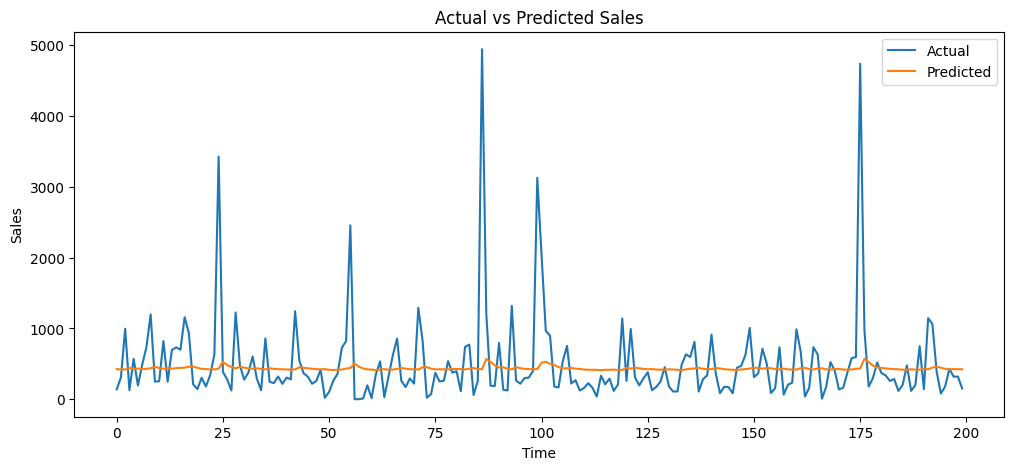

In [10]:
# Plot Actual vs Predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(actual[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [11]:
#performance matric
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 378.74414927901154
RMSE : 1327.627398402277


In [12]:
#Model save
model.save("lstm_demand_forecasting.keras")

print("LSTM model saved successfully.")

LSTM model saved successfully.


In [13]:
result = pd.DataFrame({
    "Actual": actual.flatten(),
    "Predicted": predictions.flatten()
})

result.to_csv("lstm_predictions.csv", index=False)

print("Predictions saved successfully.")

Predictions saved successfully.
